# Live NBA Game Outcome Prediction
This project aims to predict the outcome of an NBA game. It utilizes both historical and real-time data. Crucial data points include score, home court advantage, time remaining, and more as I plan to display a live probability of the possible outcomes with a logistic regression model that is trained with over 3 million basketball plays.

## 1. Imports & Functions

In [49]:
from config import data_dir, results_dir
import ipywidgets as widgets
from IPython.display import display
from load import load_playbyplay, espn_scores, get_games_on_date, load_payroll, load_win_pct
from process import process_playbyplay, process_payroll
from analyze import (
    show_correlations,
    train_model,
    predict_win_probability,
    plot_correlation_heatmap,
    plot_win_rate_by_quarter,
    plot_home_away_wins,
    plot_upset_rate,
    analyze_game
)



## 2. Load Data
Load all 6 seasons of NBA play-by-play data from Kaggle CSVs and combine them into one.
Load NBA payroll info and win percentage for 2015-2021, as well as 2026 (payroll) for live data usage.

In [50]:
pbp_raw = load_playbyplay()
print(f"Total plays loaded: {len(pbp_raw):,}") #total number of plays recorded from 2015-2021
payroll = load_payroll()
win_pct = load_win_pct()

Loaded: NBA_PBP_2017-18.csv — 590868 rows
Loaded: NBA_PBP_2019-20.csv — 539265 rows
Loaded: Payrolls.csv — 210 rows
Loaded: NBA_PBP_2016-17.csv — 596645 rows
Loaded: NBA_PBP_2018-19.csv — 614516 rows
Loaded: NBA_PBP_2020-21.csv — 97673 rows
Loaded: NBA_PBP_2015-16.csv — 601557 rows
Loaded: Win_Pct.csv — 180 rows

All seasons combined: 3040914 total rows
Total plays loaded: 3,040,914
Payroll loaded: 210 rows
Win percentage loaded: 180 rows


## 3. Process/Clean Data
Keep only the needed columns. Create a score margin column (home-away), calculate total seconds left in the game, and create the main variable (HomeWin) for the PBP data.
Merge the payroll data to correct teams and for each corresponding game.  

In [51]:

pbp = process_playbyplay(pbp_raw)
pbp = process_payroll(pbp, payroll)
print("Payroll:")
payroll.head()
print("Win Pct:")
win_pct.head()
print("Play by play:")
pbp.head()

Play-by-play processed: 3040524 rows remaining
Payroll merged: 3040524 rows remaining
Payroll:
Win Pct:
Play by play:


,WinningTeam,AwayTeam,HomeTeam,AwayScore,HomeScore,Quarter,SecLeft,Date,Location,ScoreMargin,TotalSecLeft,HomeWin,seasonStartYear,HomeTeamFull,AwayTeamFull,HomePayroll,AwayPayroll,PayrollDiff
0,CLE,BOS,CLE,0.0,0.0,1.0,720.0,2017-10-17,Quicken Loans Arena Cleveland Ohio,0.0,2880.0,1,2017,Cleveland,Boston,166597194.0,139454775.0,27142419.0
1,CLE,BOS,CLE,2.0,0.0,1.0,704.0,2017-10-17,Quicken Loans Arena Cleveland Ohio,-2.0,2864.0,1,2017,Cleveland,Boston,166597194.0,139454775.0,27142419.0
2,CLE,BOS,CLE,2.0,0.0,1.0,687.0,2017-10-17,Quicken Loans Arena Cleveland Ohio,-2.0,2847.0,1,2017,Cleveland,Boston,166597194.0,139454775.0,27142419.0
3,CLE,BOS,CLE,2.0,0.0,1.0,683.0,2017-10-17,Quicken Loans Arena Cleveland Ohio,-2.0,2843.0,1,2017,Cleveland,Boston,166597194.0,139454775.0,27142419.0
4,CLE,BOS,CLE,2.0,0.0,1.0,681.0,2017-10-17,Quicken Loans Arena Cleveland Ohio,-2.0,2841.0,1,2017,Cleveland,Boston,166597194.0,139454775.0,27142419.0


In [52]:
# Confirm that there are no missing values
#Pbp
print("Missing values per column:")
print(pbp.isnull().sum())

#Win_pct
print("\nMissing values per column:")
print(win_pct.isnull().sum())

#Payroll
print("\nMissing values per column:")
print(payroll.isnull().sum())


Missing values per column:
WinningTeam        0
AwayTeam           0
HomeTeam           0
AwayScore          0
HomeScore          0
Quarter            0
SecLeft            0
Date               0
Location           0
ScoreMargin        0
TotalSecLeft       0
HomeWin            0
seasonStartYear    0
HomeTeamFull       0
AwayTeamFull       0
HomePayroll        0
AwayPayroll        0
PayrollDiff        0
dtype: int64

Missing values per column:
team               0
win_percentage     0
seasonStartYear    0
dtype: int64

Missing values per column:
Unnamed: 0             0
team                   0
seasonStartYear        0
inflationAdjPayroll    0
dtype: int64


## 4. Correlational Analysis
Look at how strongly each variable correlates to the outcome before modeling. Score margin has a moderate to strong correlation (0.52) while time remaining has a very weak correlation. The two variables together though end up showing more info.

In [53]:
show_correlations(pbp) #showing basic correlations


Correlations with HomeWin:
              ScoreMargin  TotalSecLeft  PayrollDiff   HomeWin
ScoreMargin      1.000000     -0.057848     0.149639  0.525159
TotalSecLeft    -0.057848      1.000000     0.001174  0.001812
PayrollDiff      0.149639      0.001174     1.000000  0.193148
HomeWin          0.525159      0.001812     0.193148  1.000000


## 5. Win Rate by Quarter
Unsuprisingly, being up later in the game reveals a higher likelihood of winning.

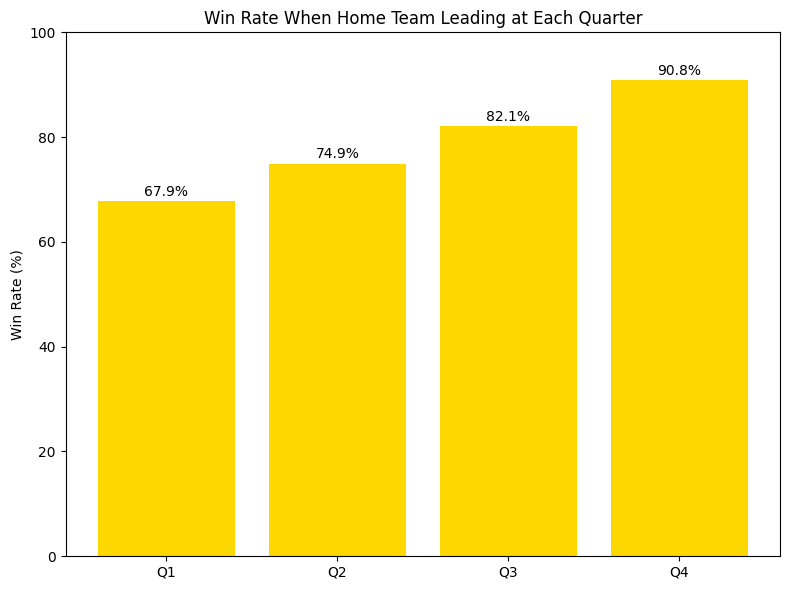

Saved: win_rate_by_quarter.png


In [54]:
plot_win_rate_by_quarter(pbp) #showing win rates at the start of each quarter from home team perspective

## 6. Home vs Away Wins
Home teams win about 58% of the time.

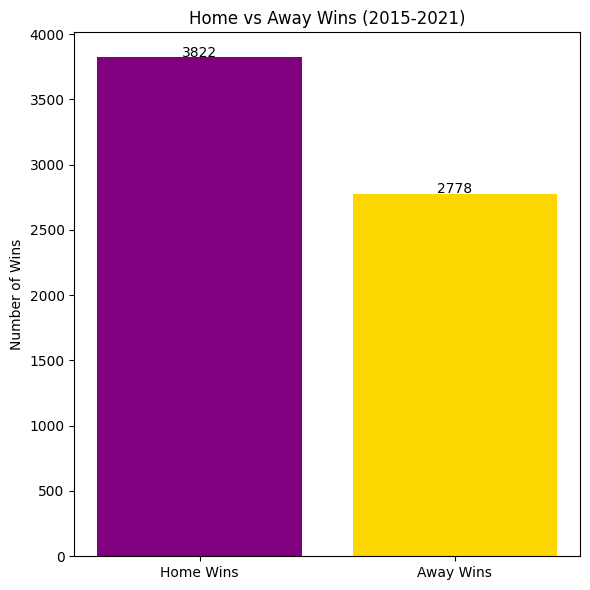

Saved: home_away_wins.png


In [55]:
plot_home_away_wins(pbp) #Simple bar chart showing home team winning vs. away team winning

## 7. Upset Rate
What percent of the time does the team with the higher payroll win? 

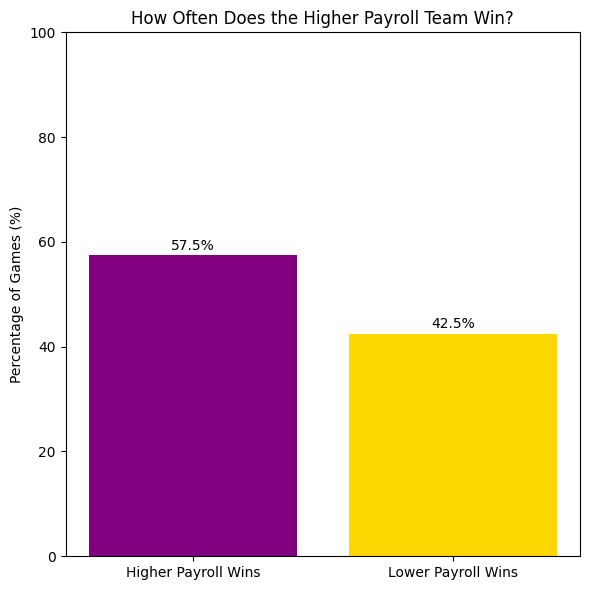

Saved: upset_rate.png


In [56]:
plot_upset_rate(pbp) #simple bar chart of % wins between who wins each game when comparing the payrolls of the two teams


## 8. Train the Model
Training a logistic regression model using score margin, time remaining, and team payroll difference as features.

In [57]:
model = train_model(pbp) 

Model Accuracy: 74.89%
Mean Squared Error: 0.25


## 9. Correlation Heatmap

The correlation heatmap shows a moderately strong relationship between ScoreMargin (leading during a game) and HomeWin. Suprisingly, there's a very weak correlation between HomeWin and PayrollDiff (having a higher payroll). 

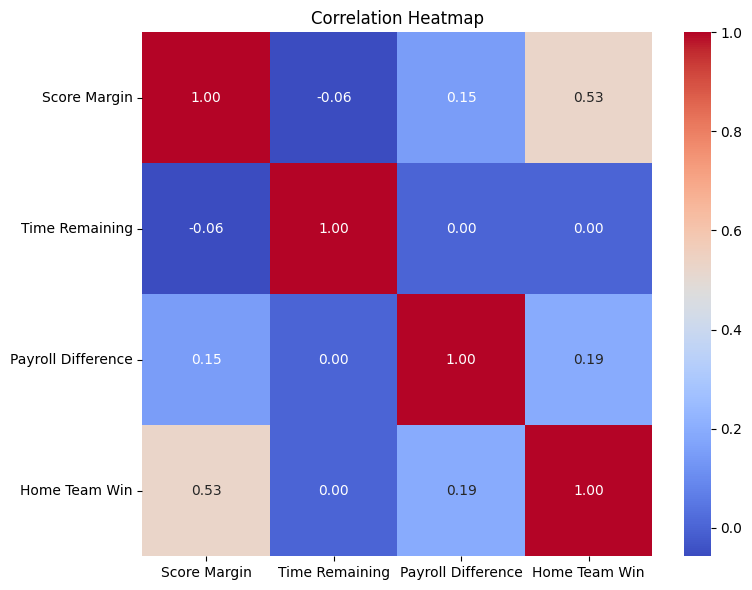

Saved: correlation_heatmap.png


In [58]:
plot_correlation_heatmap(pbp) #creating heatmap with variables scoremargin, homewin, and totalsecleft

## 10. Testing Predictions
Given random game situations, the model outputs a win probability for the home team with some tighter than others.

In [59]:
situations = [
  # first number represents margin of home team over away, with the second number representing time left in game in seconds, payroll set to zero 
    (10, 720, 0,'Start of 3rd quarter with same payroll, I expect it should heavily sway home team wins | model probability ',), 
    (10, 720, 30000000,'Start of 3rd quarter home team 30m richer, I expect it should heavily sway home team wins | model probability ',), 
    (0,60, 0, 'Game tied with a min left & same payroll, I expect it should lean slighty for home team | model probability',),
    (0,60, -20000000, 'Game tied with a min left & away team 20m higher payroll, I expect it should lean slighty for away team | model probability',),
    (-15, 1440, 0, 'Home team down 15 at half with equal payroll, I expect it should be heavy underdogs | model probability ',), 
    (3, 30, 0, 'Home team up 3 with 30 secs left in game with equal payrolls, I expect it should be moderate home team win | model probability',), 
]

for margin, secs, payroll_diff, description in situations:
    prob = predict_win_probability(model, margin, secs, payroll_diff=payroll_diff)
    print(f"{description}: {prob:.2%}")

Start of 3rd quarter with same payroll, I expect it should heavily sway home team wins | model probability : 83.69%
Start of 3rd quarter home team 30m richer, I expect it should heavily sway home team wins | model probability : 89.02%
Game tied with a min left & same payroll, I expect it should lean slighty for home team | model probability: 50.24%
Game tied with a min left & away team 20m higher payroll, I expect it should lean slighty for away team | model probability: 42.67%
Home team down 15 at half with equal payroll, I expect it should be heavy underdogs | model probability : 10.95%
Home team up 3 with 30 secs left in game with equal payrolls, I expect it should be moderate home team win | model probability: 61.43%


## 11. Choose date of game
Choose date of the NBA game to find live probability.

In [60]:
#using calendar widget found online so user can select data from game
date_picker = widgets.DatePicker(
    description='Pick a Date',
    disabled=False
)
display(date_picker)


DatePicker(value=None, description='Pick a Date', step=1)

## 12. Game selection
Select the exact game given the previously chosen date. 

In [62]:
date =  date_picker.value
games = get_games_on_date(date)
games_names_list = list(games.keys())

#using radio widget found online so user can select data from game
radio = widgets.RadioButtons(
    options= games_names_list,
    value=games_names_list[0], # Default selected value
    description='Choose game:',
    disabled=False
)
display(radio)


RadioButtons(description='Choose game:', options=('Detroit Pistons at Charlotte Hornets', 'Miami Heat at Washi…

## 13. Live prediction with known ESPN play-by-play data
 Given ESPN play-by-play data from _________, the model outputs a win probability for the home team for each play.


Payroll loaded: 210 rows
Payroll loaded: 210 rows


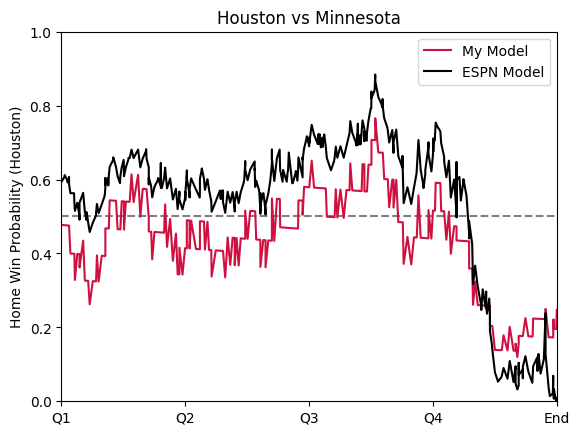

saved:espn_vs_model.png
Biggest play: Home team has 66 and away team has 66 with 3:23 left in quarter 2. Play: Terrence Shannon Jr. makes 25-foot three point step back jumpshot.


In [63]:
game_selected = radio.value
game_id = games[game_selected]
game_info = espn_scores(game_id)
analyze_game(game_info['plays_list'], model, game_info['home_team'], game_info['away_team'], game_info['home_team_color'])
